# Expanded PPO Search Analysis

This notebook expands the existing search-analysis workflow by combining **Optuna SQLite analysis** and **Weights & Biases run analysis**.

The goal is not only to identify the best trial, but to understand:

- which hyperparameters matter most
- which architectural choices appear repeatedly among strong trials
- whether strong performance comes from broad robustness or only from a subset of demand levels
- what trade-offs exist between reward, queue length, waiting time, and speed
- which regions of the search space look promising for future runs


In [1]:
import math
import re
import warnings
from pathlib import Path

import numpy as np
import optuna
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 140

DB_PATH = 'sqlite:///ppo_search_120.db'
STUDY_NAME = 'ppo_sumo_bo_120'
TOPK = 10
TOP_FRACTION = 0.15

study = optuna.load_study(study_name=STUDY_NAME, storage=DB_PATH)
df = study.trials_dataframe(attrs=('number','value','state','params','user_attrs','system_attrs','datetime_start','datetime_complete'))
df['duration_h'] = (pd.to_datetime(df['datetime_complete']) - pd.to_datetime(df['datetime_start'])).dt.total_seconds() / 3600
dfc = df.copy()
completed = dfc[dfc['state'] == 'COMPLETE'].copy()
param_cols = [c for c in dfc.columns if c.startswith('params_')]
num_param_cols = [c for c in param_cols if pd.api.types.is_numeric_dtype(dfc[c])]
cat_param_cols = [c for c in param_cols if c not in num_param_cols]

print('Trials:', len(dfc))
print('Completed:', len(completed))
print('Best value:', study.best_value)
print('Best trial:', study.best_trial.number)


Trials: 229
Completed: 122
Best value: -3.5342574847268704
Best trial: 123


## 1. Search-Level Summary

These views answer whether the search ran cleanly, how expensive trials were, and how quickly the study improved.

In [2]:
summary = pd.DataFrame({
    'n_trials': [len(dfc)],
    'n_complete': [(dfc['state'] == 'COMPLETE').sum()],
    'n_pruned': [(dfc['state'] == 'PRUNED').sum()],
    'n_fail': [(dfc['state'] == 'FAIL').sum()],
    'best_value': [study.best_value],
    'median_complete_value': [completed['value'].median()],
    'mean_duration_h_complete': [completed['duration_h'].mean()],
})
summary.T


,0
n_trials,229.000000
n_complete,122.000000
n_pruned,99.000000
n_fail,2.000000
best_value,-3.534257
median_complete_value,-7.558000
mean_duration_h_complete,0.986997


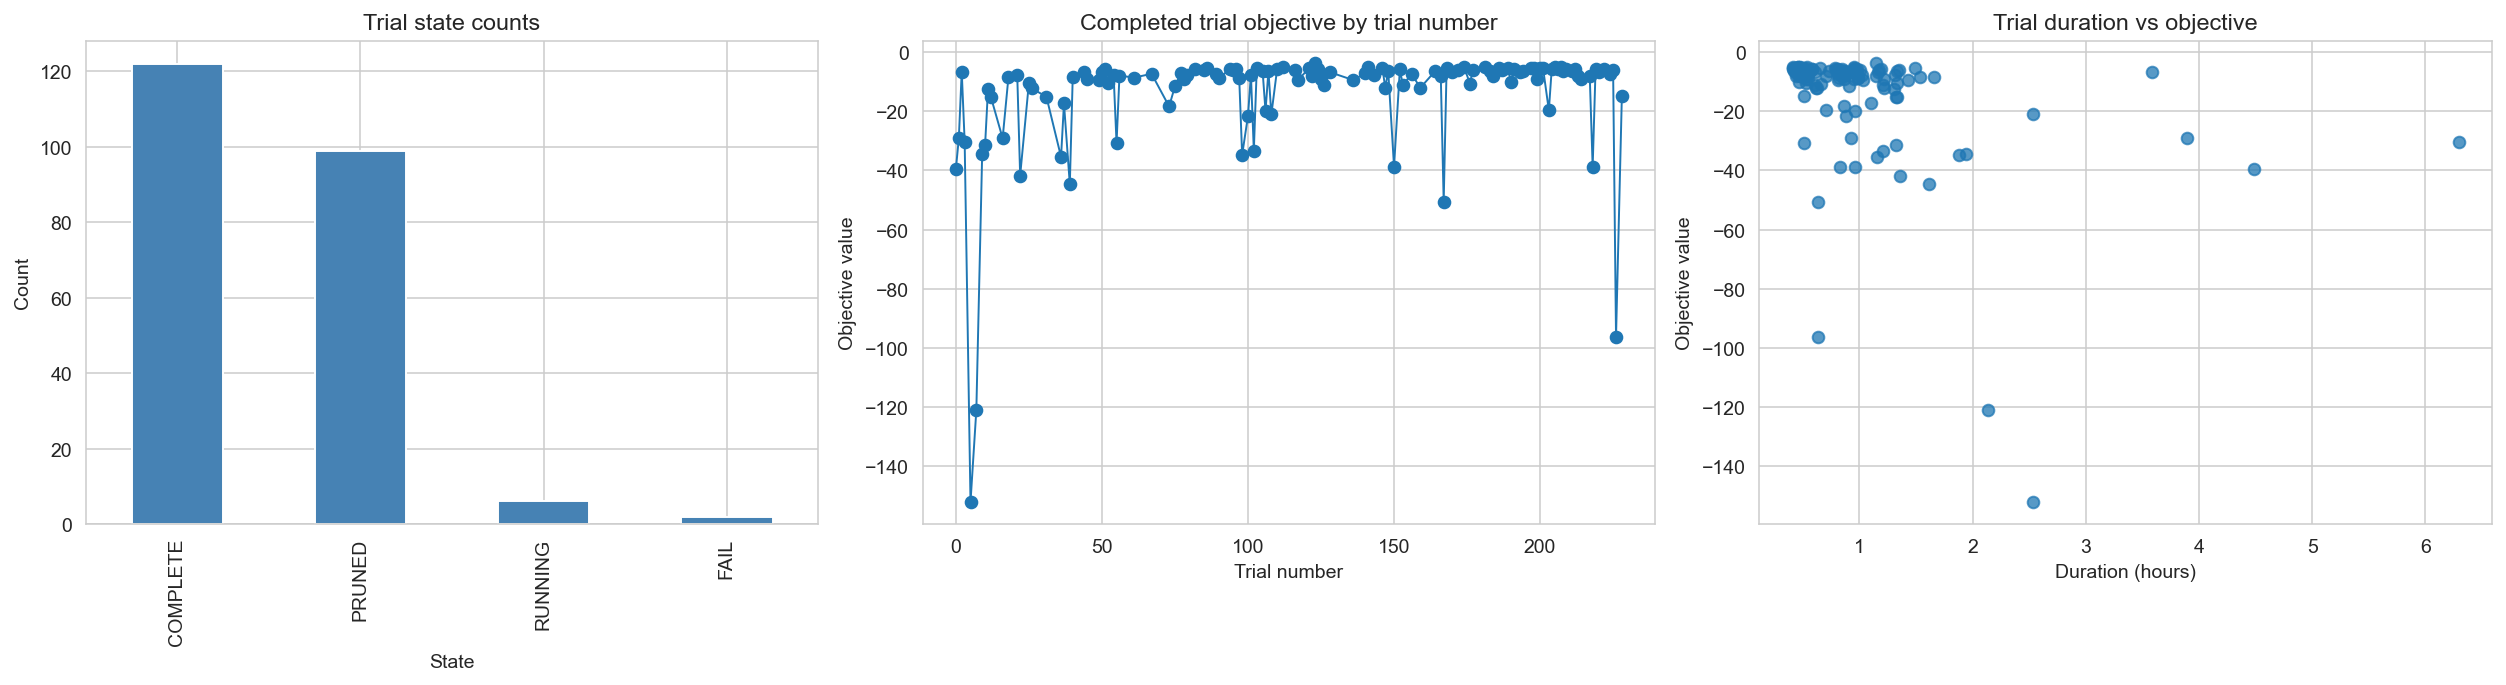

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

dfc['state'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Trial state counts')
axes[0].set_xlabel('State')
axes[0].set_ylabel('Count')

axes[1].plot(completed['number'], completed['value'], marker='o', linewidth=1)
axes[1].set_title('Completed trial objective by trial number')
axes[1].set_xlabel('Trial number')
axes[1].set_ylabel('Objective value')

axes[2].scatter(completed['duration_h'], completed['value'], alpha=0.75)
axes[2].set_title('Trial duration vs objective')
axes[2].set_xlabel('Duration (hours)')
axes[2].set_ylabel('Objective value')

plt.tight_layout()
plt.show()


## 2. Hyperparameter Importance and Search Geometry

These views are useful for deciding where future search effort should go.

### Why These Parameters Matter

- `num_conv_layers`, `num_filter_*`, `kernel_size_*`, and `stride_size_*` control how aggressively the state grid is compressed and which spatial traffic patterns can be represented. In this problem, they determine whether the policy can separate lane-level occupancy structure from broader congestion patterns.
- `lstm_units` controls temporal memory. This matters because the signal controller does not only react to a static snapshot; it benefits from encoding queue growth, dissipation, and short-term demand changes over time.
- `num_mlp_layers` and `mlp_neurons_*` control the capacity of the decision head after the convolutional and recurrent encoders. Larger heads can model more complex policy and value mappings, but may also overfit or become harder to optimize.
- `learning_rate`, `optimizer`, and `L2-reg` affect optimization stability. For PPO in particular, unstable optimizer settings can dominate architectural effects if they lead to noisy or prematurely collapsed updates.
- `K_epochs` and `clip_range` control how strongly PPO reuses each rollout. Larger reuse can improve sample efficiency, but can also move the policy too far from the data-collection policy if clipping is not sufficiently restrictive.
- `gamma` and `lambd` control credit assignment over time. In traffic signal control, these parameters shape whether the agent focuses on immediate queue relief or on longer-term network flow quality.
- `entropy_coef` controls exploration pressure. Low entropy can freeze the controller into brittle timing patterns, while high entropy can prevent convergence to decisive phase choices.

When reading the plots below, keep in mind that some parameters are conditional. For example, `num_filter_1` only matters when the sampled architecture actually has a second convolutional layer. Empty or weak-looking effects can therefore be caused by search sparsity rather than by genuine irrelevance.

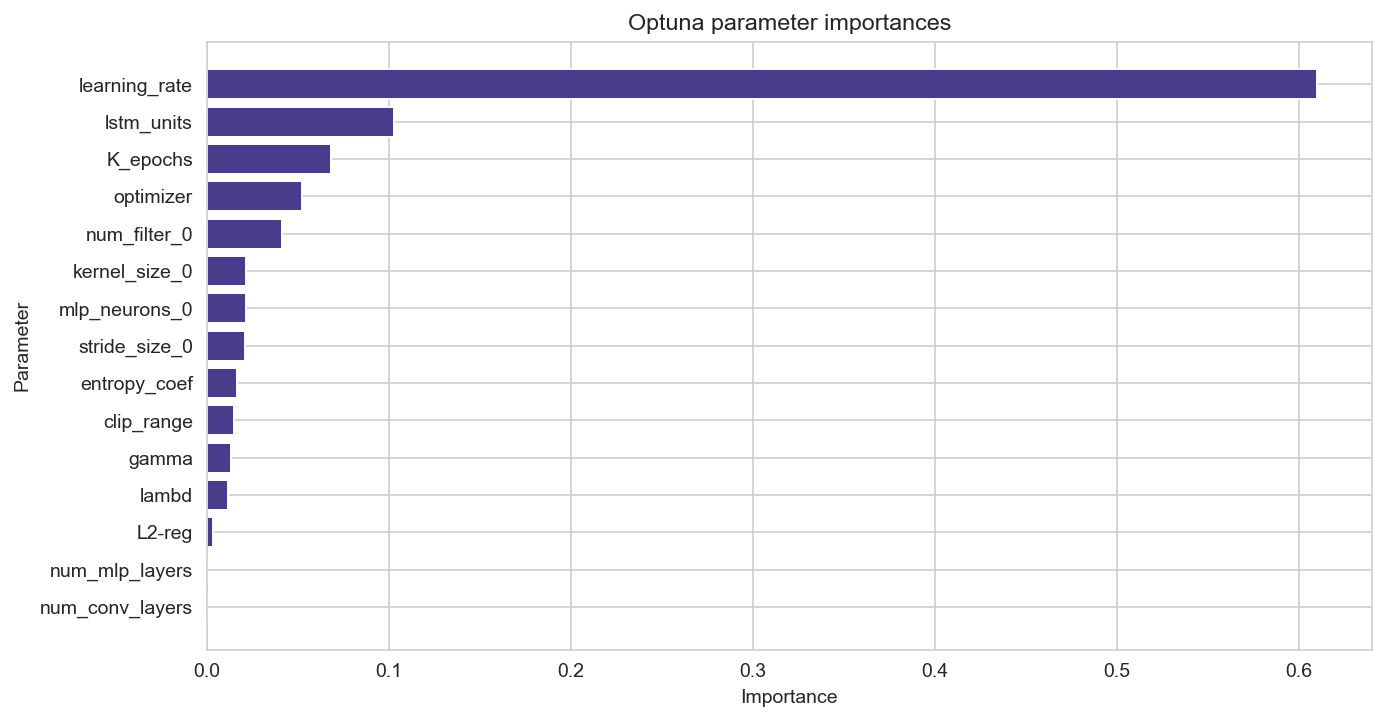

,param,importance
0,learning_rate,6.097207e-01
1,lstm_units,1.032372e-01
2,K_epochs,6.813258e-02
3,optimizer,5.269079e-02
4,num_filter_0,4.145139e-02
5,kernel_size_0,2.161705e-02
6,mlp_neurons_0,2.143561e-02
7,stride_size_0,2.109574e-02
8,entropy_coef,1.683139e-02
9,clip_range,1.508108e-02


In [4]:
from optuna.importance import get_param_importances

imps = get_param_importances(study)
imp_df = pd.DataFrame({'param': list(imps.keys()), 'importance': list(imps.values())}).sort_values('importance', ascending=True)
plt.figure(figsize=(10, max(5, 0.35 * len(imp_df))))
plt.barh(imp_df['param'], imp_df['importance'], color='darkslateblue')
plt.title('Optuna parameter importances')
plt.xlabel('Importance')
plt.ylabel('Parameter')
plt.tight_layout()
plt.show()
imp_df.sort_values('importance', ascending=False)


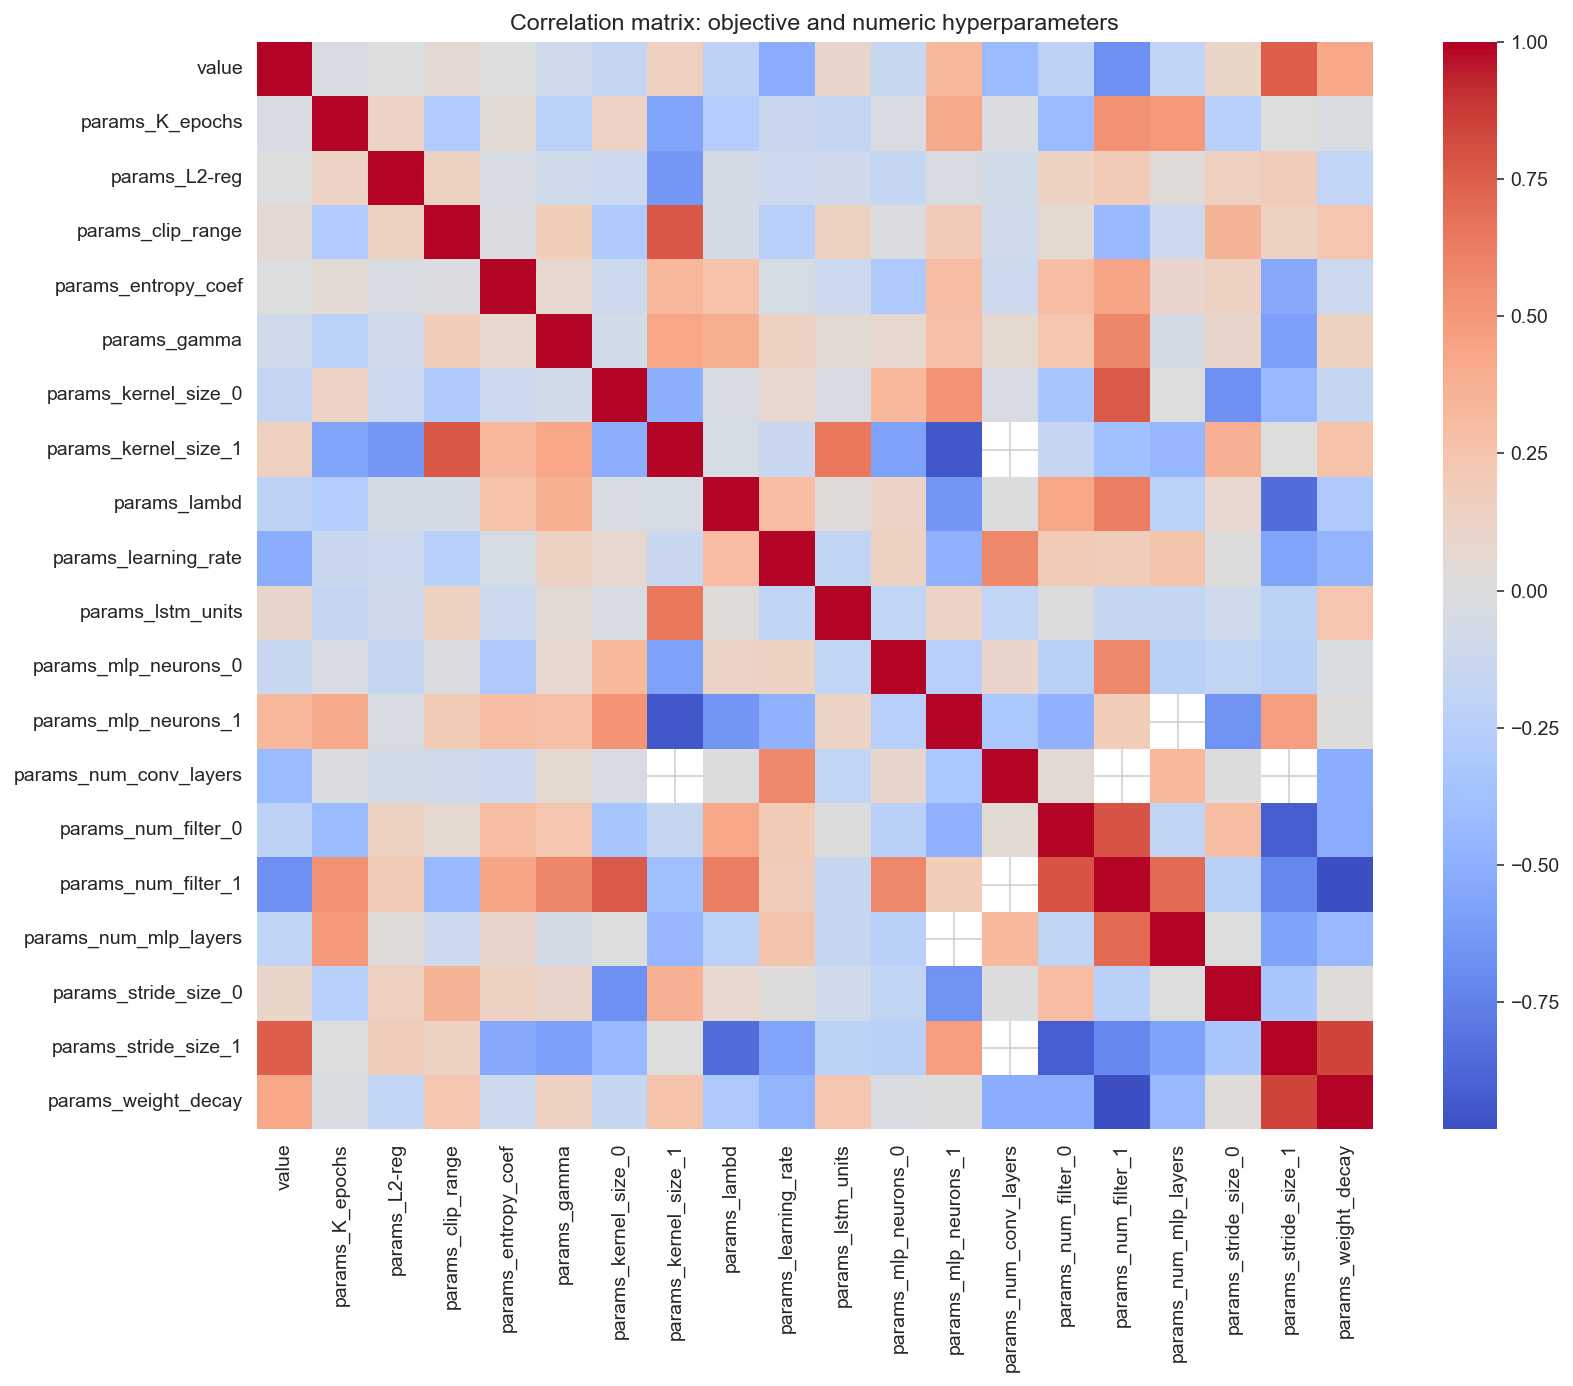

In [5]:
corr_cols = ['value'] + num_param_cols
corr_df = completed[corr_cols].corr(numeric_only=True)
plt.figure(figsize=(12, 10))
sns.heatmap(corr_df, cmap='coolwarm', center=0)
plt.title('Correlation matrix: objective and numeric hyperparameters')
plt.tight_layout()
plt.show()


,number,value,params_K_epochs,params_L2-reg,params_clip_range,params_entropy_coef,params_gamma,params_kernel_size_0,params_kernel_size_1,params_lambd,...,params_mlp_neurons_0,params_mlp_neurons_1,params_num_conv_layers,params_num_filter_0,params_num_filter_1,params_num_mlp_layers,params_optimizer,params_stride_size_0,params_stride_size_1,params_weight_decay
123,123,-3.534257,14,8.196045e-04,0.19,0.008906,0.980,3,NaN,0.93,...,32,64.0,1,16,NaN,3,adam,3,NaN,NaN
205,205,-4.947032,7,3.303819e-04,0.23,0.002596,0.982,5,NaN,0.92,...,128,NaN,1,32,NaN,2,adamw,3,NaN,0.000020
181,181,-4.994750,6,3.222115e-08,0.24,0.004619,0.985,5,NaN,0.92,...,128,NaN,1,16,NaN,2,adamw,2,NaN,0.000034
141,141,-5.077778,10,2.222831e-06,0.20,0.006193,0.980,5,NaN,0.93,...,32,64.0,1,16,NaN,3,adam,3,NaN,NaN
174,174,-5.084939,5,2.472293e-08,0.23,0.004122,0.985,3,NaN,0.92,...,128,NaN,1,16,NaN,2,adamw,3,NaN,0.000043
207,207,-5.090601,7,2.779463e-06,0.22,0.001492,0.981,3,NaN,0.92,...,128,NaN,1,32,NaN,2,adamw,3,NaN,0.000023
112,112,-5.132471,9,2.490393e-04,0.23,0.006878,0.985,3,NaN,0.93,...,32,64.0,1,16,NaN,3,adam,3,NaN,NaN
186,186,-5.159498,7,5.227613e-09,0.20,0.003352,0.980,3,NaN,0.92,...,128,NaN,1,16,NaN,2,adamw,3,NaN,0.000049
198,198,-5.179788,5,9.507404e-06,0.23,0.002353,0.982,3,NaN,0.92,...,128,NaN,1,32,NaN,2,adamw,3,NaN,0.000022
146,146,-5.193117,9,1.533615e-07,0.22,0.009492,0.988,7,NaN,0.92,...,32,128.0,1,16,NaN,3,adam,2,NaN,NaN


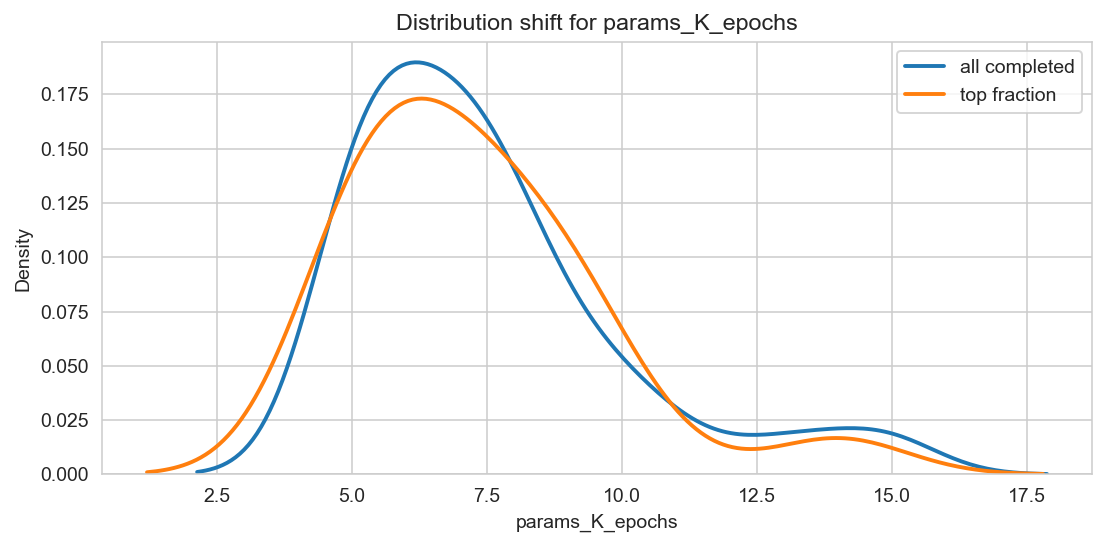

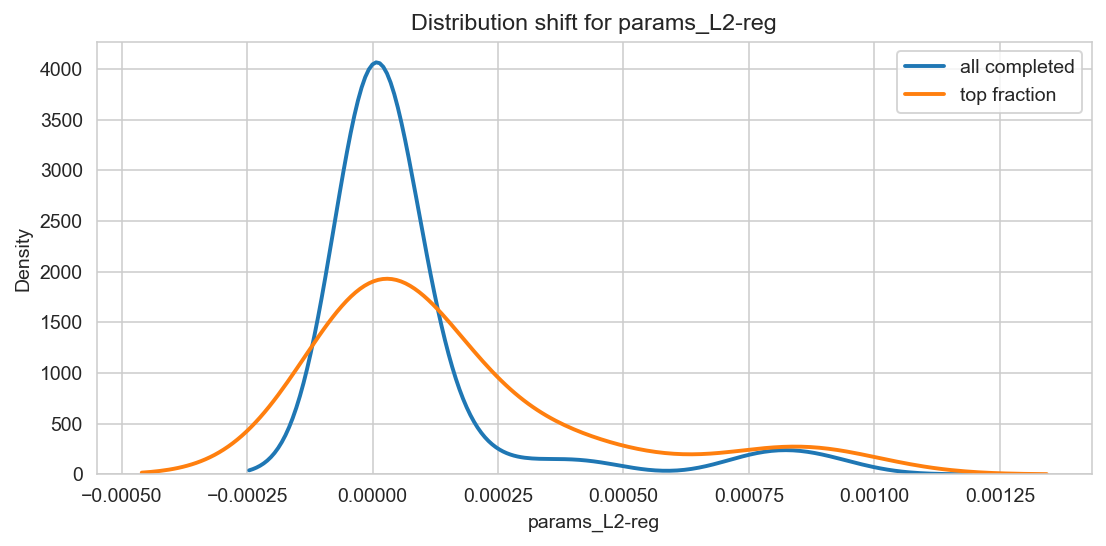

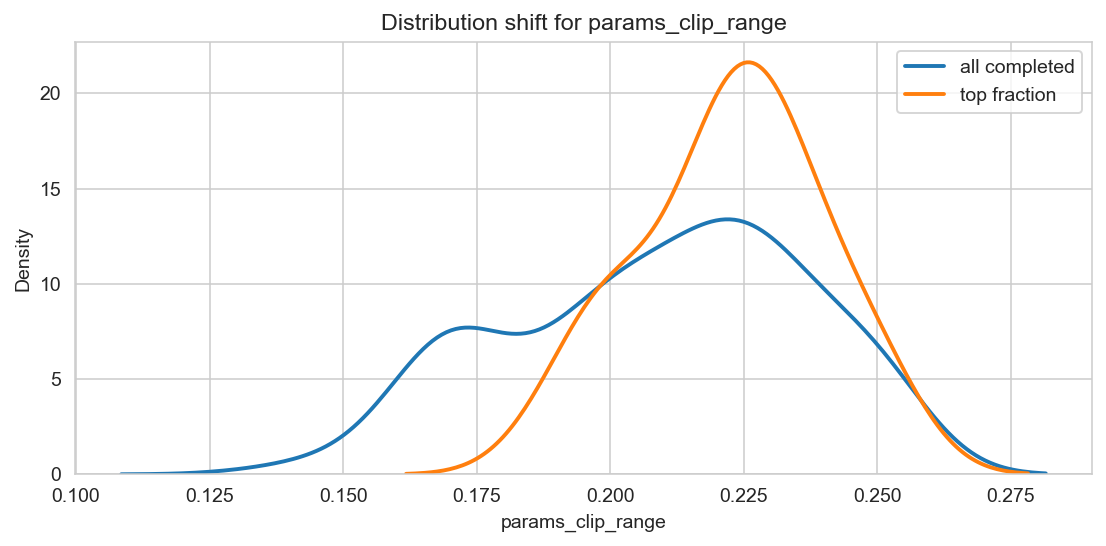

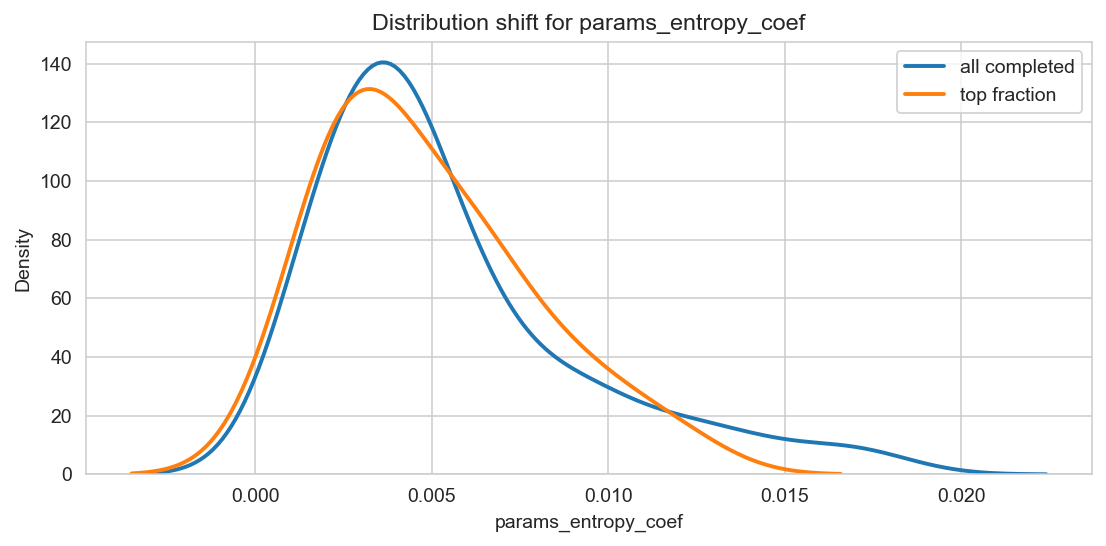

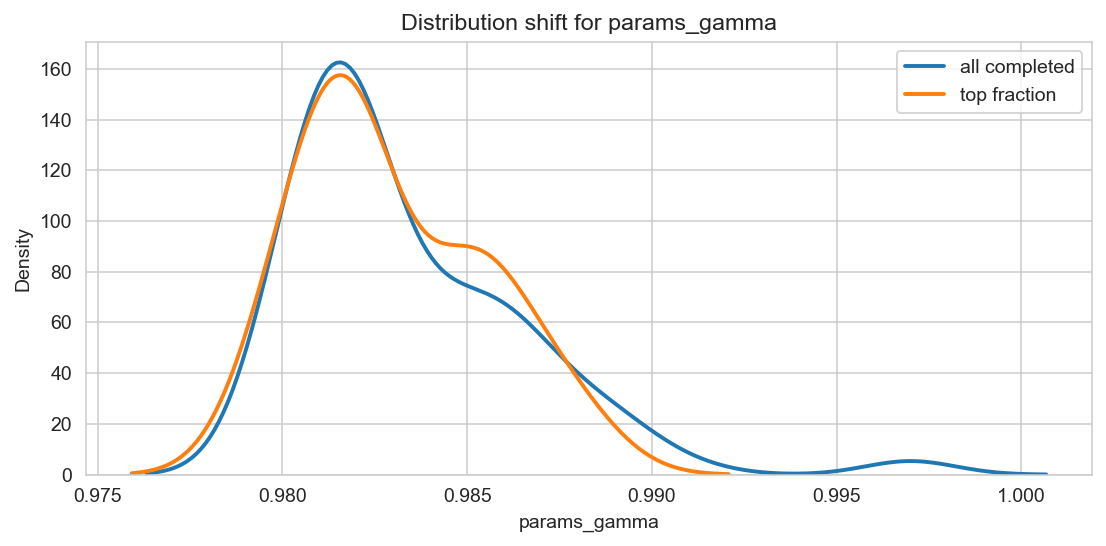

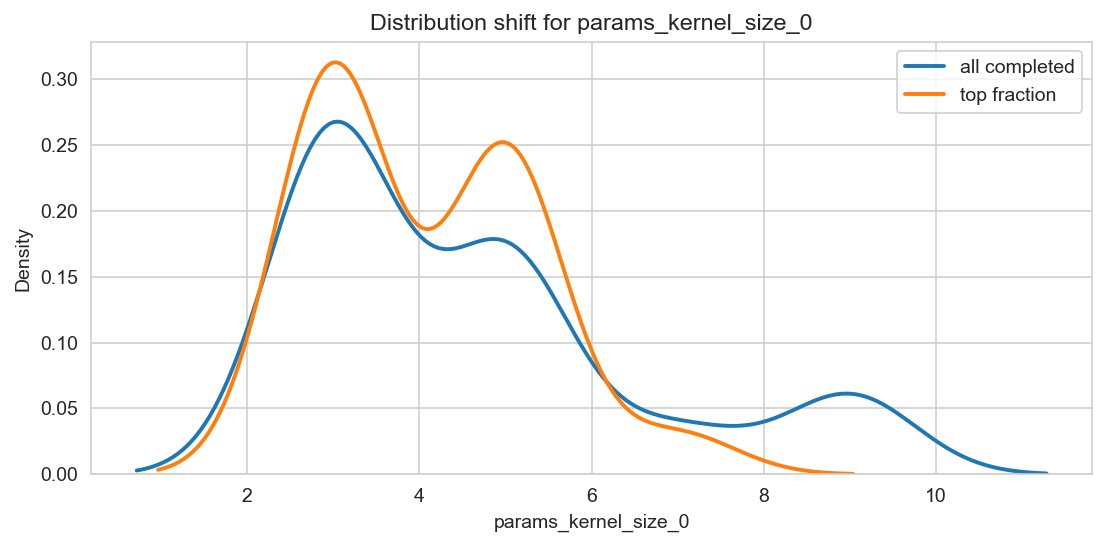

In [6]:
top_cut = max(1, int(math.ceil(len(completed) * TOP_FRACTION)))
top_df = completed.sort_values('value', ascending=False).head(top_cut).copy()

display(top_df[['number', 'value'] + param_cols].head(TOPK))

for col in num_param_cols[:6]:
    plt.figure(figsize=(8, 4))
    sns.kdeplot(completed[col].dropna(), label='all completed', linewidth=2)
    sns.kdeplot(top_df[col].dropna(), label='top fraction', linewidth=2)
    plt.title(f'Distribution shift for {col}')
    plt.legend()
    plt.tight_layout()
    plt.show()


## 3. Architecture Patterns Among Strong Trials

This section highlights recurring design choices in the best part of the search space.

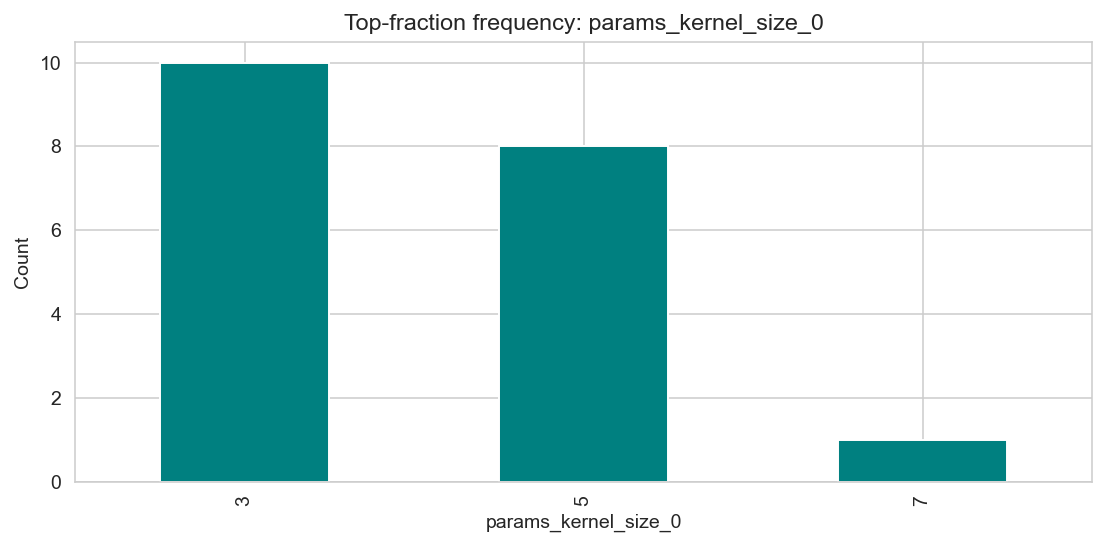

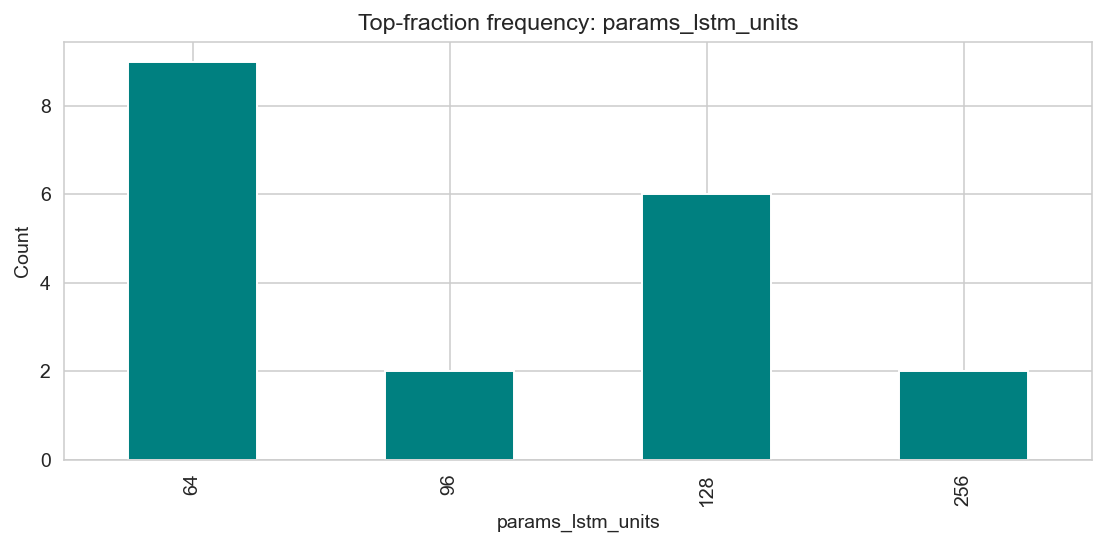

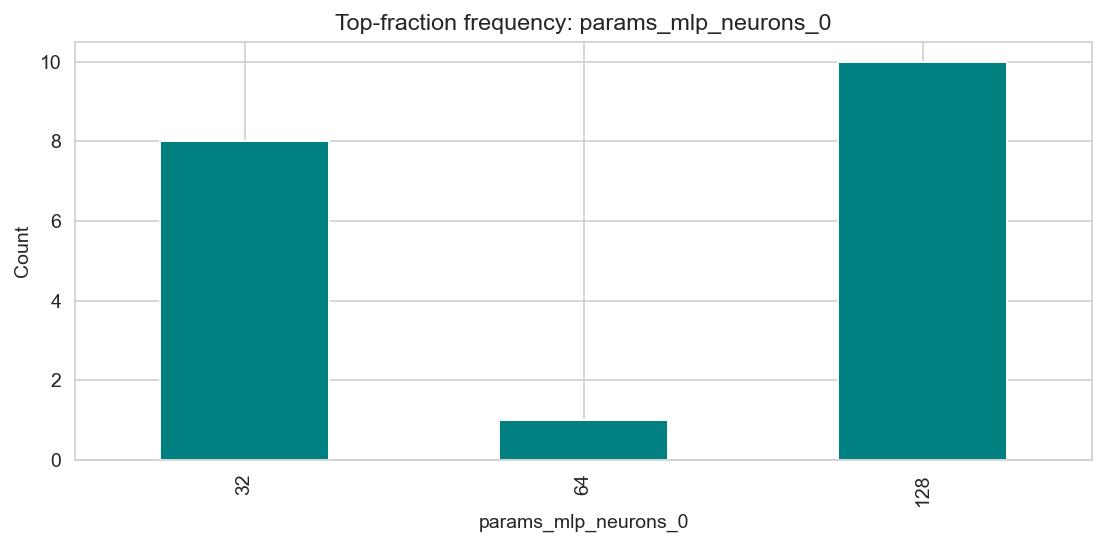

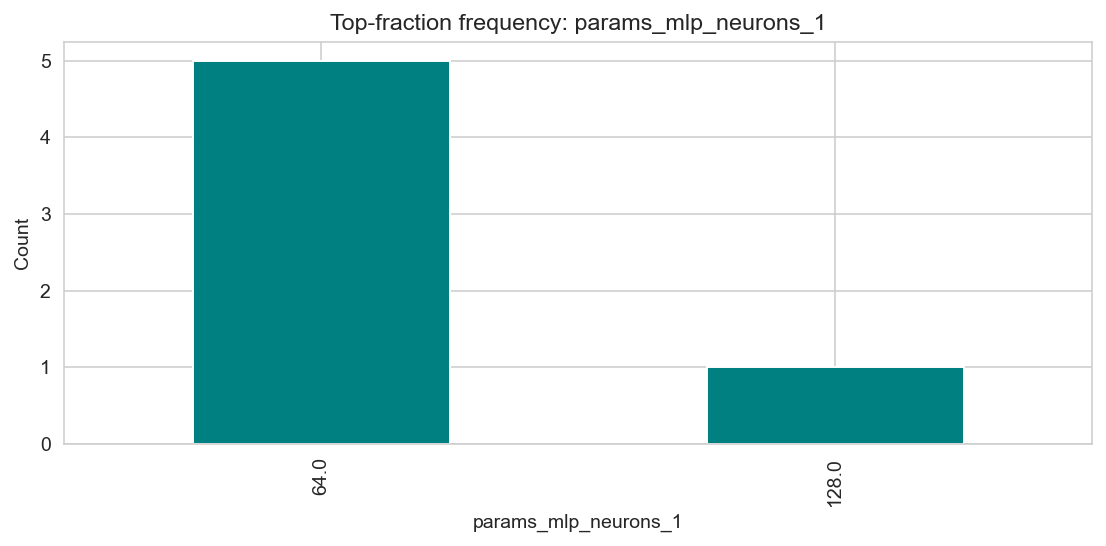

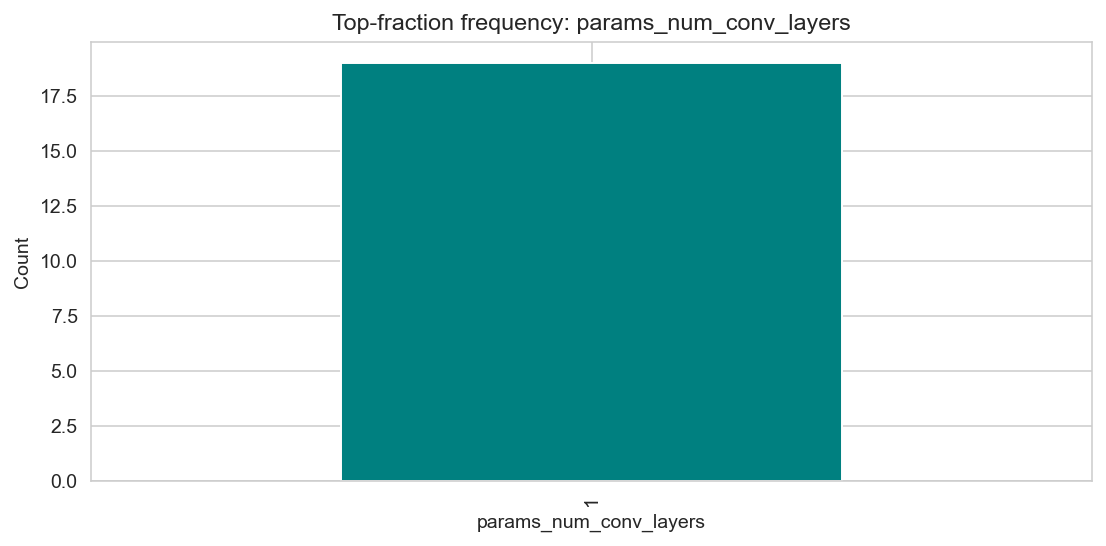

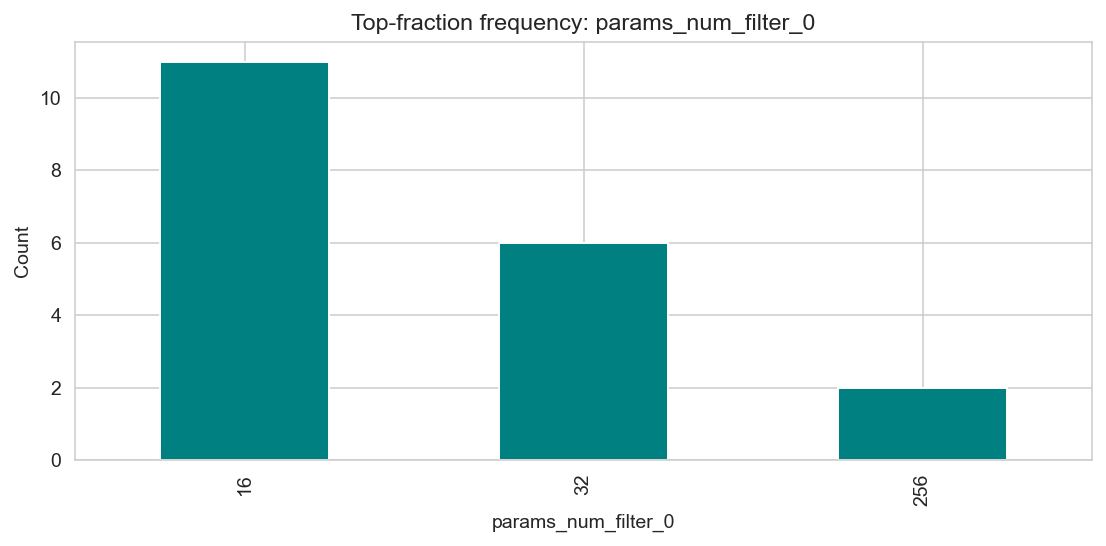

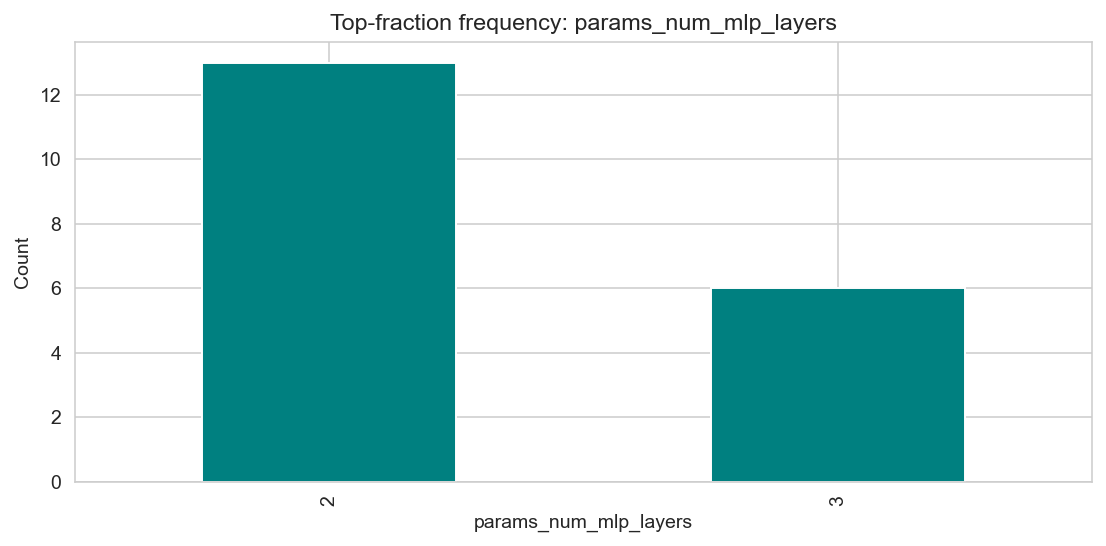

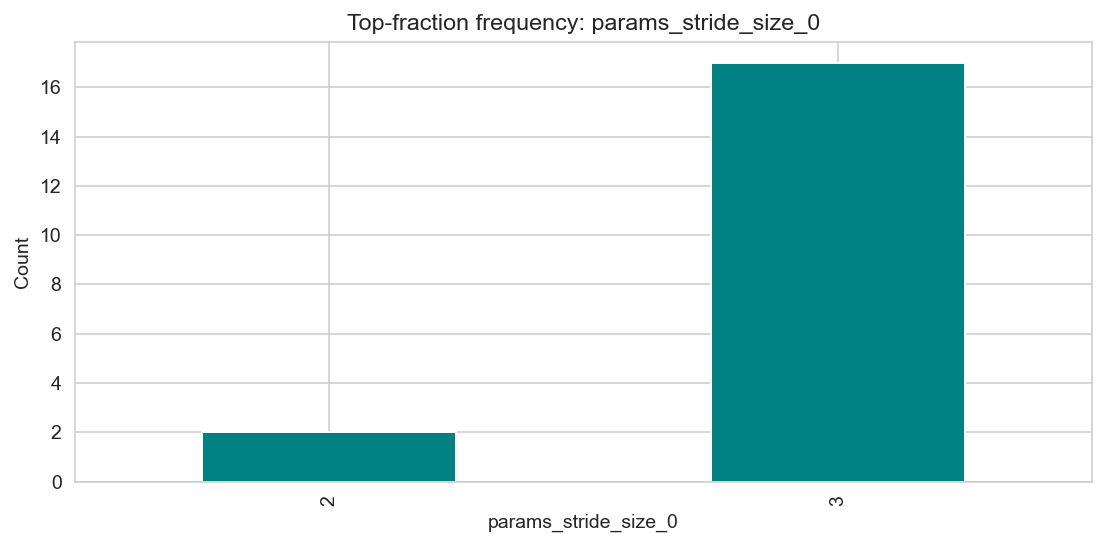

In [7]:
arch_cols = [c for c in param_cols if any(k in c for k in ['num_conv_layers', 'num_filter_', 'kernel_size_', 'stride_size_', 'lstm_units', 'num_mlp_layers', 'mlp_neurons_'])]
top_arch = top_df[arch_cols].copy()
top_arch = top_arch.dropna(axis=1, how='all')

if top_arch.empty:
    print('No architecture columns with observed values in the selected top-fraction trials.')
else:
    for col in top_arch.columns:
        vc = top_arch[col].dropna().value_counts().sort_index()
        if vc.empty:
            print(f'Skipping {col}: no observed values in the selected top-fraction trials.')
            continue
        plt.figure(figsize=(8, 4))
        vc.plot(kind='bar', color='teal')
        plt.title(f'Top-fraction frequency: {col}')
        plt.xlabel(col)
        plt.ylabel('Count')
        plt.tight_layout()
        plt.show()


### Top-3 Trial Comparison

The next block puts the best three completed trials side by side, including both architecture and PPO optimization parameters. This is useful for checking whether strong trials repeatedly favor the same depth, widths, memory size, or PPO update regime rather than only looking good in isolation.

In [15]:
top3 = completed.sort_values('value', ascending=False).head(3).copy()

architecture_cols = [
    'params_num_conv_layers', 'params_num_filter_0', 'params_num_filter_1',
    'params_kernel_size_0', 'params_kernel_size_1', 'params_stride_size_0', 'params_stride_size_1',
    'params_lstm_units', 'params_num_mlp_layers', 'params_mlp_neurons_0', 'params_mlp_neurons_1'
]
ppo_cols = [
    'params_learning_rate', 'params_K_epochs', 'params_L2-reg', 'params_gamma',
    'params_lambd', 'params_clip_range', 'params_entropy_coef', 'params_optimizer'
]

selected_cols = ['number', 'value'] + [c for c in architecture_cols + ppo_cols if c in top3.columns]
rename_map = {c: c.replace('params_', '') for c in selected_cols if c.startswith('params_')}

#display(top3[selected_cols].rename(columns=rename_map).reset_index(drop=True))

print(top3[selected_cols].rename(columns=rename_map).reset_index(drop=True))

top3[selected_cols].rename(columns=rename_map).reset_index(drop=True).to_csv("./top3_arch.csv", index=False)

shared_rows = []
for col in [c for c in selected_cols if c.startswith('params_')]:
    vals = top3[col].dropna()
    if vals.empty:
        continue
    counts = vals.value_counts()
    if counts.iloc[0] >= 2:
        shared_rows.append({
            'parameter': col.replace('params_', ''),
            'most_common_value': counts.index[0],
            'count_within_top3': int(counts.iloc[0]),
        })

shared_df = pd.DataFrame(shared_rows).sort_values(['count_within_top3', 'parameter'], ascending=[False, True]) if shared_rows else pd.DataFrame(columns=['parameter', 'most_common_value', 'count_within_top3'])
display(shared_df)


   number     value  num_conv_layers  num_filter_0  num_filter_1  \
0     123 -3.534257                1            16           NaN   
1     205 -4.947032                1            32           NaN   
2     181 -4.994750                1            16           NaN   

   kernel_size_0  kernel_size_1  stride_size_0  stride_size_1  lstm_units  \
0              3            NaN              3            NaN         128   
1              5            NaN              3            NaN          64   
2              5            NaN              2            NaN         256   

   ...  mlp_neurons_0  mlp_neurons_1  learning_rate  K_epochs        L2-reg  \
0  ...             32           64.0       0.000010        14  8.196045e-04   
1  ...            128            NaN       0.000024         7  3.303819e-04   
2  ...            128            NaN       0.000012         6  3.222115e-08   

   gamma  lambd  clip_range  entropy_coef  optimizer  
0  0.980   0.93        0.19      0.008906     

,parameter,most_common_value,count_within_top3
0,num_conv_layers,1,3
2,kernel_size_0,5,2
6,lambd,0.92,2
5,mlp_neurons_0,128,2
1,num_filter_0,16,2
4,num_mlp_layers,2,2
7,optimizer,adamw,2
3,stride_size_0,3,2


## 4. W&B Run Analysis

This section enriches the SQLite search analysis with the per-demand evaluation metrics logged to Weights & Biases.

Edit the `ENTITY` and `PROJECT` values if needed.

In [16]:
import wandb

ENTITY = 'jzapanag'
PROJECT = 'TrafficSignalControl'
OBJECTIVE_KEY = 'eval/weighted_avg'
MODE = 'max'
TOPK_RUNS = 10
WB_FILTERS = {'state': 'finished'}

api = wandb.Api(timeout=60)
runs = api.runs(f'{ENTITY}/{PROJECT}', filters=WB_FILTERS)

def family(summary, prefix):
    out = {}
    pat = re.compile(rf'^{re.escape(prefix)}(\d+)$')
    for k, v in (summary or {}).items():
        if not isinstance(k, str):
            continue
        m = pat.match(k)
        if m:
            try:
                out[int(m.group(1))] = float(v)
            except Exception:
                pass
    return out

rows = []
for r in runs:
    summ = dict(r.summary or {})
    cfg = dict(r.config or {})
    search_space = cfg.get('search_space', {})
    obj = summ.get(OBJECTIVE_KEY)
    if obj is None:
        continue
    rows.append({
        'name': r.name,
        'run_id': r.id,
        'url': f'https://wandb.ai/{ENTITY}/{PROJECT}/runs/{r.id}',
        OBJECTIVE_KEY: float(obj),
        'score_by_vol': family(summ, 'eval/score@'),
        'speed_by_vol': family(summ, 'eval/avg_speed@'),
        'queue_by_vol': family(summ, 'eval/avg_queue_length@'),
        'wait_by_vol': family(summ, 'eval/cumulative_wait@'),
        **{f'cfg_{k}': v for k, v in search_space.items() if isinstance(v, (int, float, str, bool)) or v is None}
    })

wandb_df = pd.DataFrame(rows)
ascending = MODE.lower() == 'min'
top_runs = wandb_df.sort_values(OBJECTIVE_KEY, ascending=ascending).head(TOPK_RUNS).reset_index(drop=True)
top_runs[['name', 'run_id', OBJECTIVE_KEY, 'url']]


,name,run_id,eval/weighted_avg,url
0,trial-123-v7,s1uwv6gd,-3.534257,https://wandb.ai/jzapanag/TrafficSignalControl...
1,trial-205-v7,w992iuy2,-4.947032,https://wandb.ai/jzapanag/TrafficSignalControl...
2,trial-181-v7,h7apurol,-4.994750,https://wandb.ai/jzapanag/TrafficSignalControl...
3,trial-141-v7,lt06ect8,-5.077778,https://wandb.ai/jzapanag/TrafficSignalControl...
4,trial-174-v7,i95wk2qd,-5.084939,https://wandb.ai/jzapanag/TrafficSignalControl...
5,trial-207-v7,6bjy5tgj,-5.090601,https://wandb.ai/jzapanag/TrafficSignalControl...
6,trial-112-v7,zibncuvu,-5.132471,https://wandb.ai/jzapanag/TrafficSignalControl...
7,trial-186-v7,zu1flv6b,-5.159498,https://wandb.ai/jzapanag/TrafficSignalControl...
8,trial-198-v7,1hp24g43,-5.179788,https://wandb.ai/jzapanag/TrafficSignalControl...
9,trial-251-v7,u52h5fx5,-5.190296,https://wandb.ai/jzapanag/TrafficSignalControl...


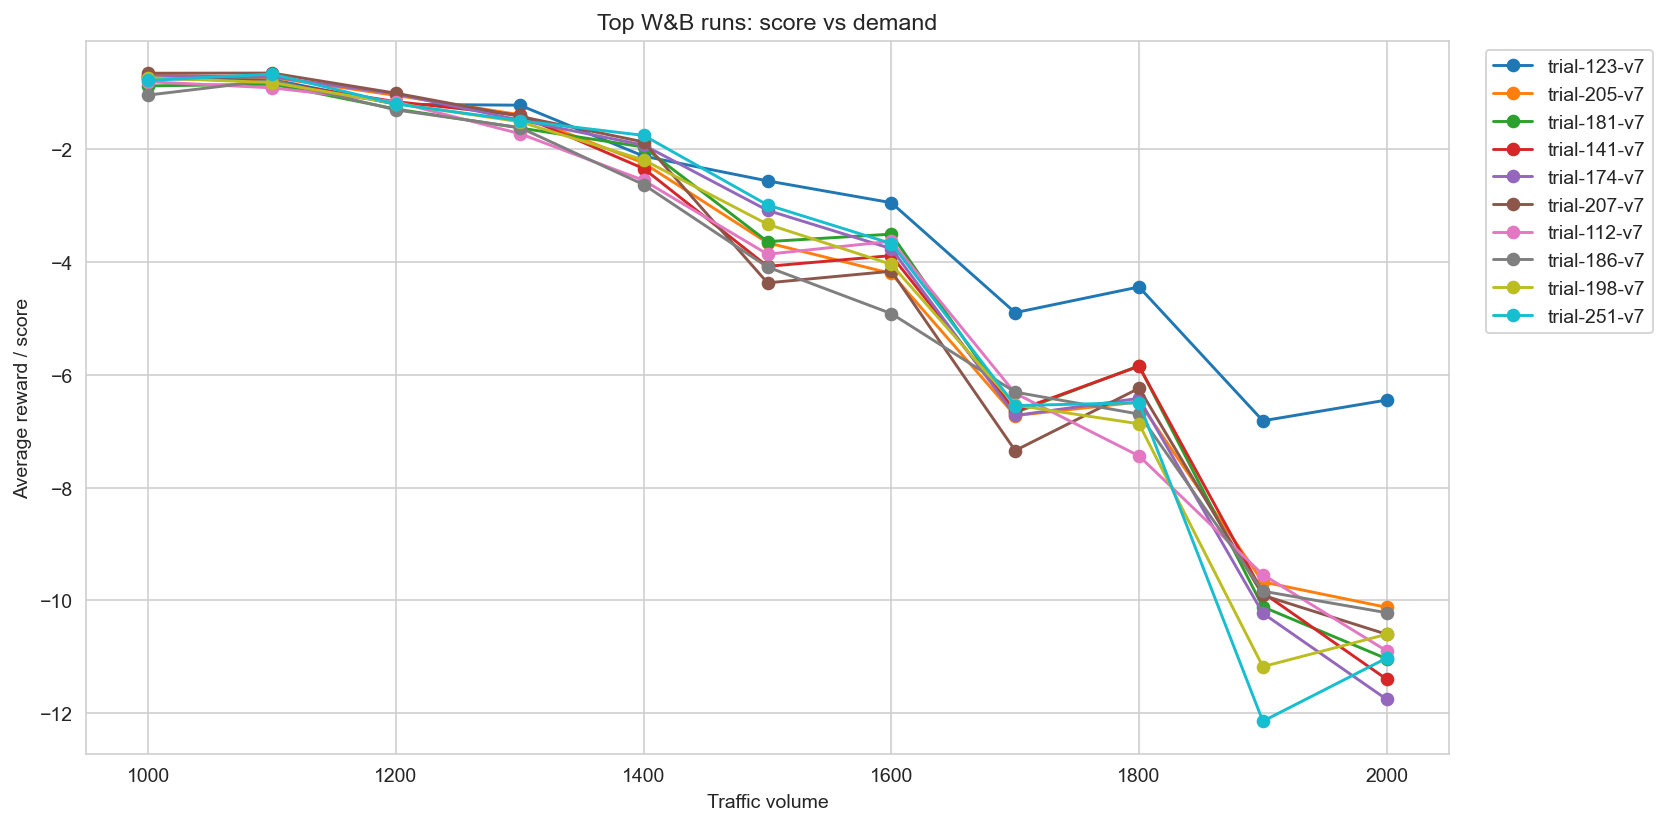

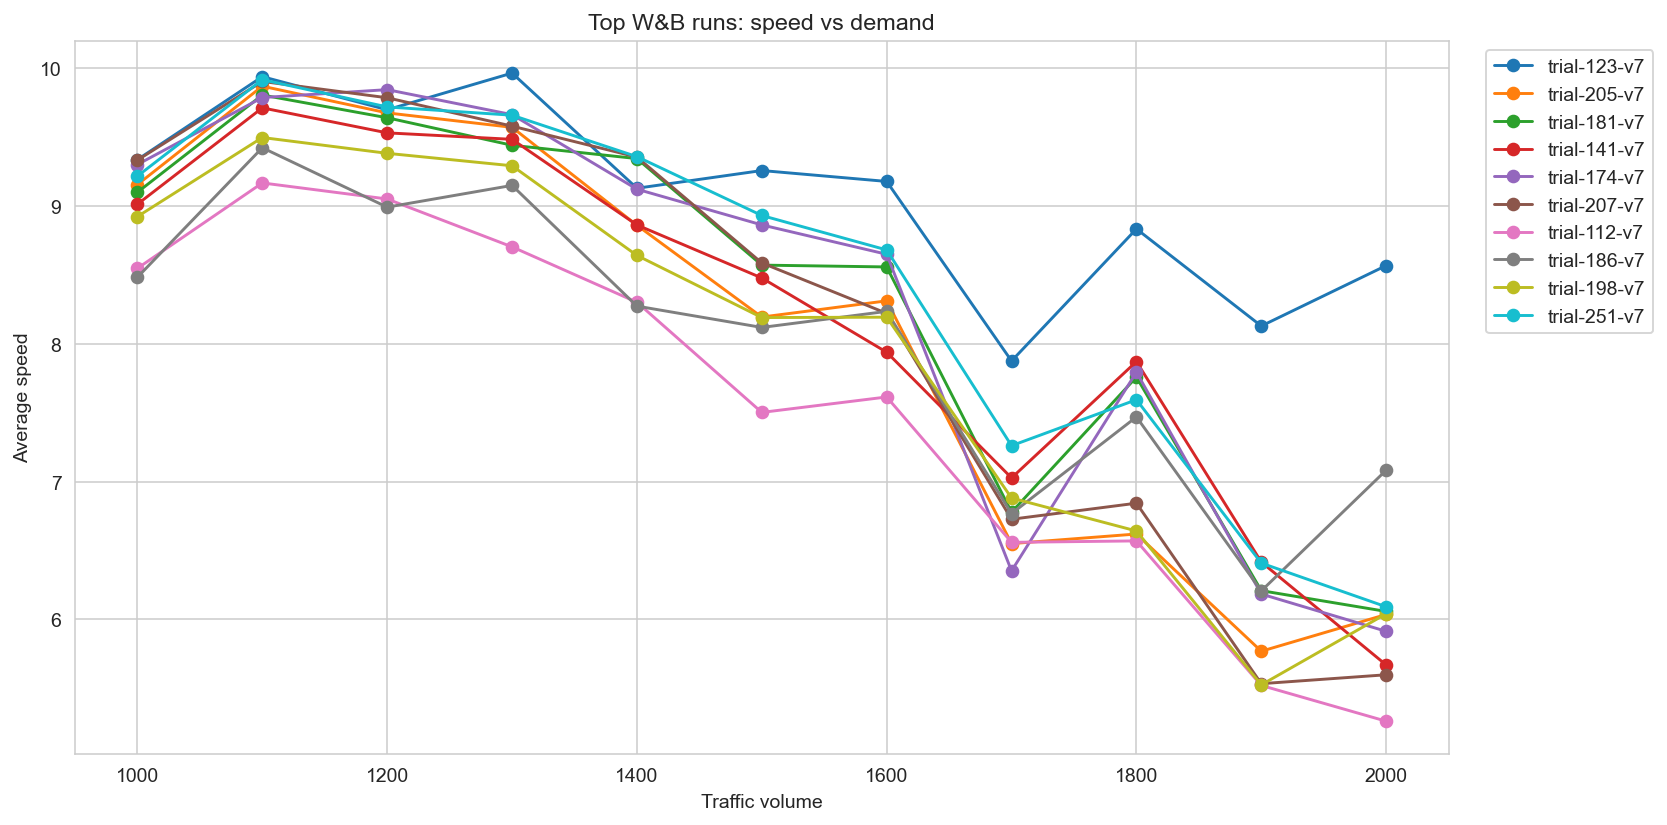

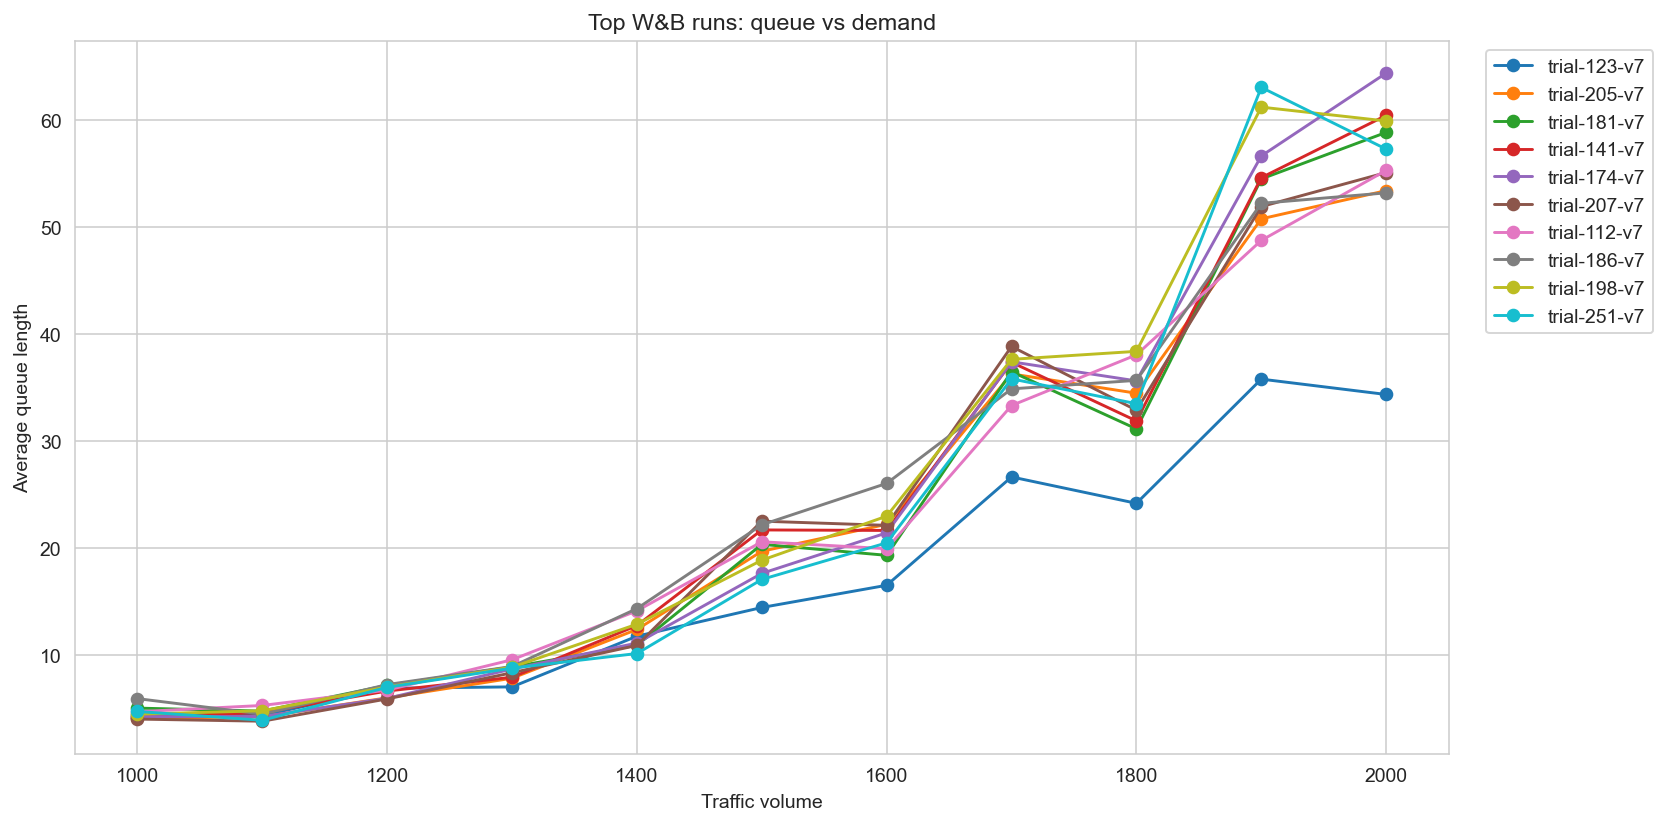

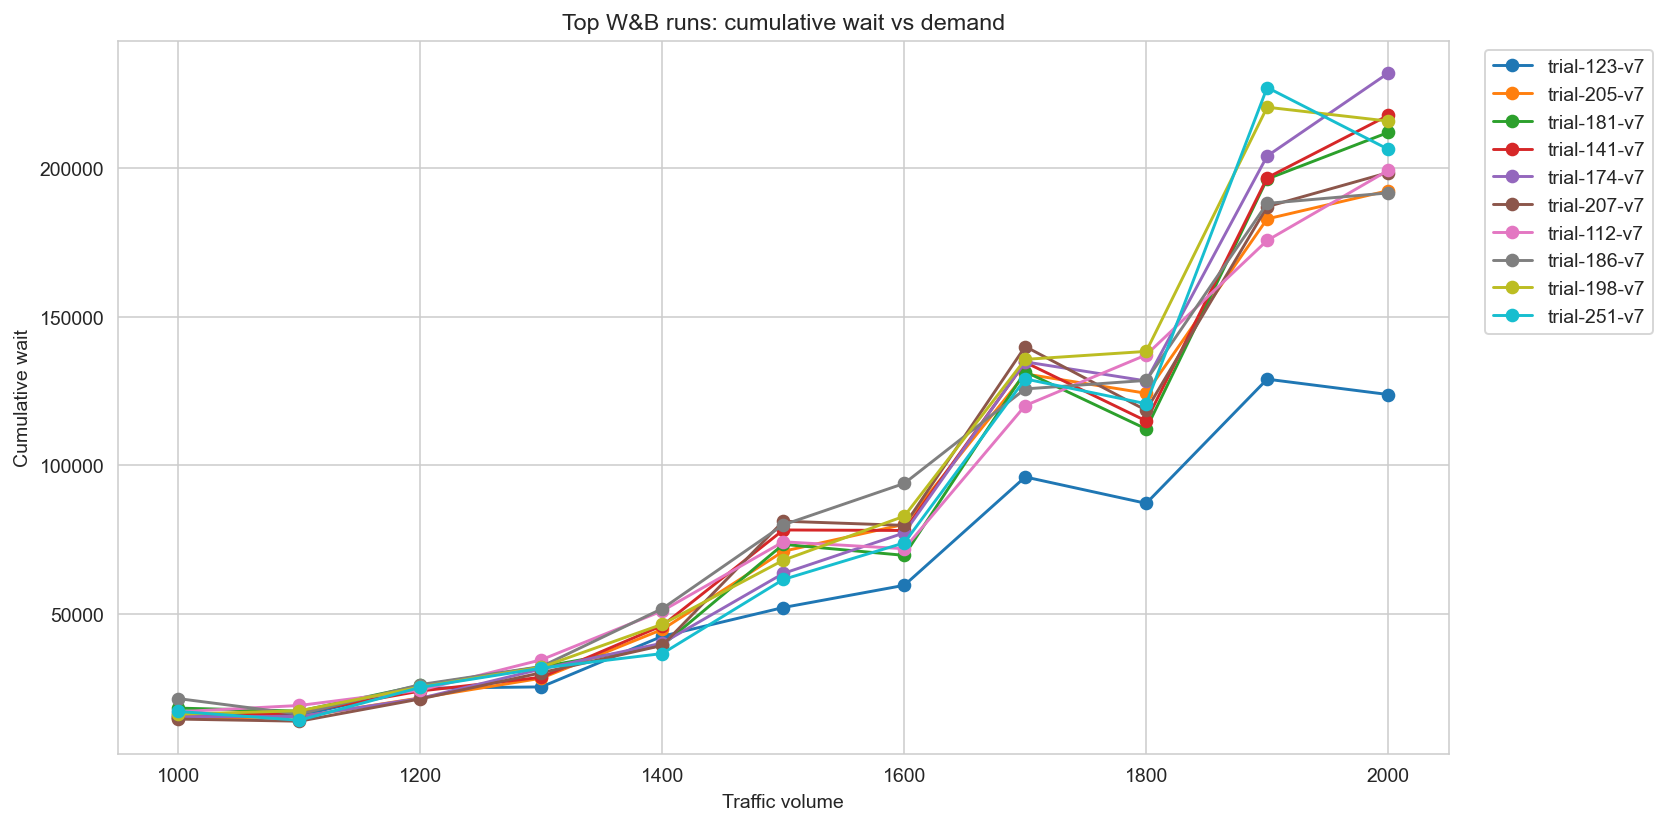

In [17]:
def expand_metric(df, dict_col, prefix):
    all_vols = sorted(set(v for d in df[dict_col] for v in (d or {}).keys()))
    out = df.copy()
    for vol in all_vols:
        out[f'{prefix}@{vol}'] = out[dict_col].apply(lambda d: d.get(vol, np.nan) if isinstance(d, dict) else np.nan)
    return out, all_vols

top_runs_exp, vols = expand_metric(top_runs, 'score_by_vol', 'score')
top_runs_exp, _ = expand_metric(top_runs_exp, 'speed_by_vol', 'speed')
top_runs_exp, _ = expand_metric(top_runs_exp, 'queue_by_vol', 'queue')
top_runs_exp, _ = expand_metric(top_runs_exp, 'wait_by_vol', 'wait')

def plot_family_lines(df, prefix, ylabel, title):
    cols = [c for c in df.columns if c.startswith(prefix + '@')]
    vols = sorted(int(c.split('@')[1]) for c in cols)
    cols = [f'{prefix}@{v}' for v in vols]
    plt.figure(figsize=(12, 6))
    for _, row in df.iterrows():
        plt.plot(vols, row[cols].astype(float).values, marker='o', label=row['name'])
    plt.title(title)
    plt.xlabel('Traffic volume')
    plt.ylabel(ylabel)
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

plot_family_lines(top_runs_exp, 'score', 'Average reward / score', 'Top W&B runs: score vs demand')
plot_family_lines(top_runs_exp, 'speed', 'Average speed', 'Top W&B runs: speed vs demand')
plot_family_lines(top_runs_exp, 'queue', 'Average queue length', 'Top W&B runs: queue vs demand')
plot_family_lines(top_runs_exp, 'wait', 'Cumulative wait', 'Top W&B runs: cumulative wait vs demand')


,name,eval/weighted_avg,score_mean,score_std,score_min,score_max,score_range,score_slope
0,trial-123-v7,-3.534257,-3.106452,2.119588,-6.815232,-0.749709,6.065523,-0.006417
1,trial-205-v7,-4.947032,-4.268991,3.342506,-10.122946,-0.691315,9.431631,-0.010171
2,trial-181-v7,-4.994750,-4.308934,3.484853,-11.035143,-0.846897,10.188246,-0.010287
3,trial-141-v7,-5.077778,-4.376412,3.522928,-11.397691,-0.715140,10.682551,-0.010520
4,trial-174-v7,-5.084939,-4.346570,3.728847,-11.755344,-0.699407,11.055937,-0.011076
5,trial-207-v7,-5.090601,-4.383814,3.513748,-10.600940,-0.649593,9.951347,-0.010602
6,trial-112-v7,-5.132471,-4.440860,3.419808,-10.896151,-0.803067,10.093085,-0.010374
7,trial-186-v7,-5.159498,-4.492913,3.268318,-10.218515,-0.776189,9.442326,-0.009999


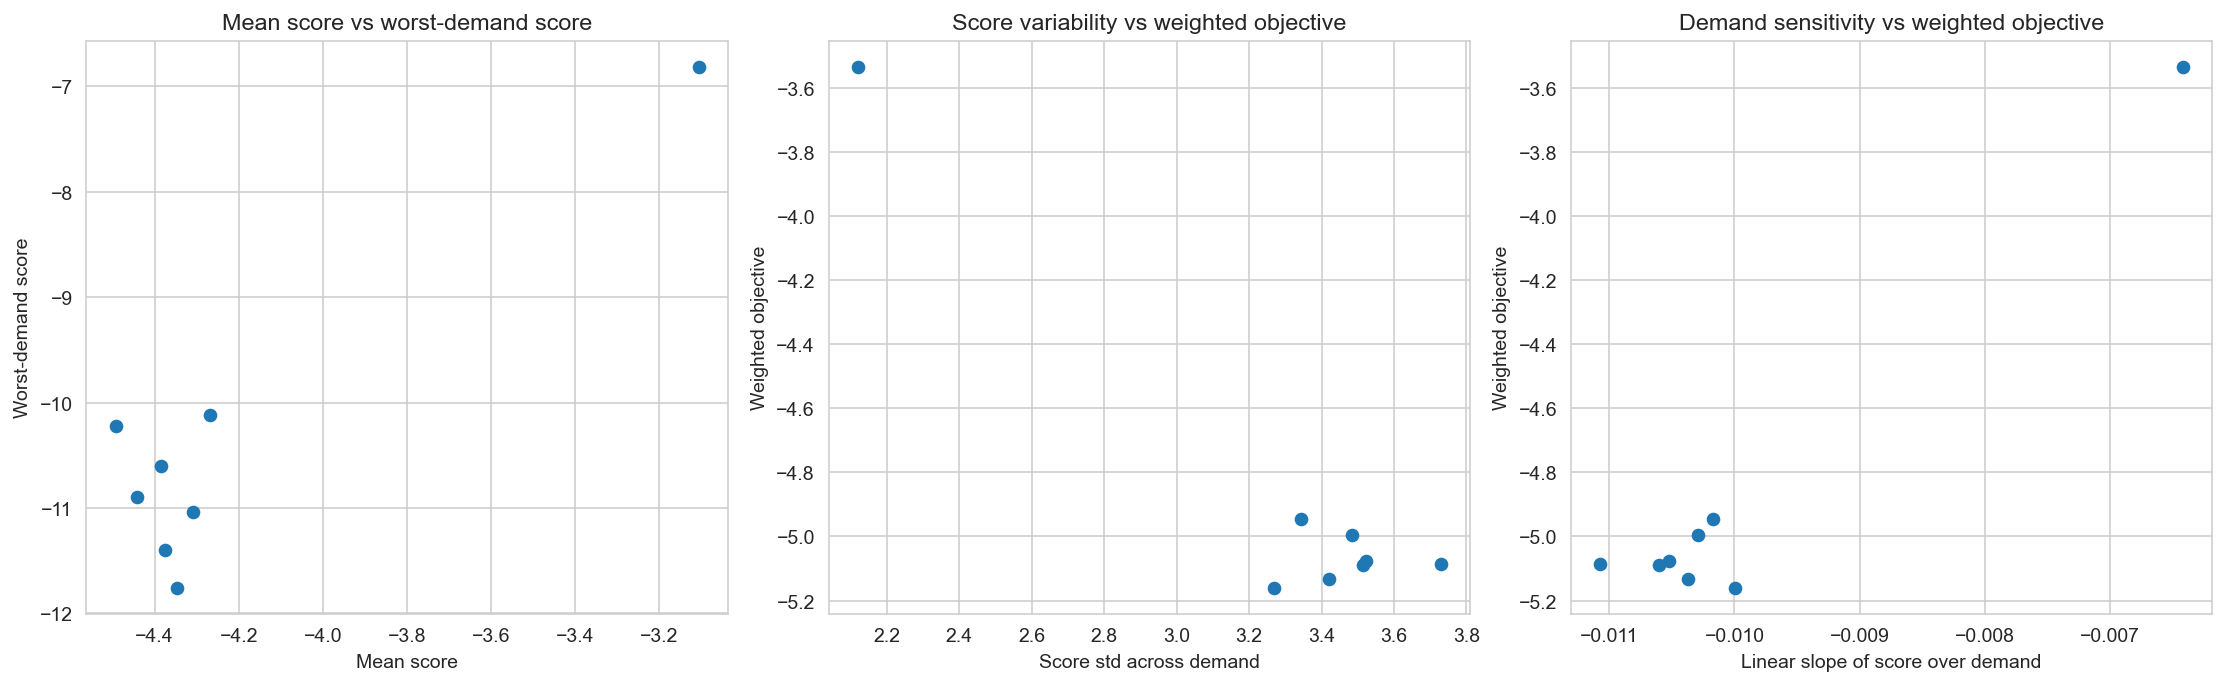

In [11]:
def robustness_features(row):
    vols = sorted(row['score_by_vol'].keys())
    scores = np.array([row['score_by_vol'][v] for v in vols], dtype=float)
    x = np.array(vols, dtype=float)
    slope = np.polyfit(x, scores, 1)[0] if len(scores) >= 2 else np.nan
    return pd.Series({
        'score_mean': scores.mean(),
        'score_std': scores.std(),
        'score_min': scores.min(),
        'score_max': scores.max(),
        'score_range': scores.max() - scores.min(),
        'score_slope': slope,
    })

robust_df = pd.concat([top_runs[['name', OBJECTIVE_KEY]], top_runs.apply(robustness_features, axis=1)], axis=1)
display(robust_df.sort_values(OBJECTIVE_KEY, ascending=False))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].scatter(robust_df['score_mean'], robust_df['score_min'])
axes[0].set_title('Mean score vs worst-demand score')
axes[0].set_xlabel('Mean score')
axes[0].set_ylabel('Worst-demand score')

axes[1].scatter(robust_df['score_std'], robust_df[OBJECTIVE_KEY])
axes[1].set_title('Score variability vs weighted objective')
axes[1].set_xlabel('Score std across demand')
axes[1].set_ylabel('Weighted objective')

axes[2].scatter(robust_df['score_slope'], robust_df[OBJECTIVE_KEY])
axes[2].set_title('Demand sensitivity vs weighted objective')
axes[2].set_xlabel('Linear slope of score over demand')
axes[2].set_ylabel('Weighted objective')

plt.tight_layout()
plt.show()


## 5. Opportunities for Additional Analysis

The most promising additions, depending on the final paper direction, are:

- compare **top-fraction parameter distributions** against the full search space to identify stable design preferences
- compare **best weighted score** against **worst-demand score** to separate peak performance from robustness
- analyze **trial duration vs score** to quantify cost-quality trade-offs
- inspect whether some architectural choices systematically reduce queue length or waiting time even when reward is similar
- perform **top-trial family plots** for score, speed, queue, and wait to identify cross-demand behavior patterns
- compute robustness descriptors such as score standard deviation, slope over demand, and minimum-demand performance
- analyze **pruned vs completed** regions of the search space to avoid repeatedly sampling weak settings in future studies

These views are especially useful for identifying next-step improvements rather than only reporting the best run.